# Quick Start Guide to LangChain

#### Ignoring the Warning

In [2]:
import warnings
warnings.filterwarnings("ignore", message="Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.")

Google recently updated their SDK to recommend using a different method (Chat.send_message) for agents that use tools or function calling. Because LangChain's internal code hasn't fully migrated to this new method yet, Google's SDK prints this warning.

In [ ]:
from dotenv import load_dotenv
from pprint import pprint
from langchain.agents import create_agent
from langchain.messages import HumanMessage

agent = create_agent(model="google_genai:gemini-2.5-flash")

result = agent.invoke({"messages": [HumanMessage(content= "What is the current weather of Lahore?")]})

pprint(result)

In [ ]:
print(result['messages'][-1].content)


### 9. ReAct Framework (Reasoning and Action)

![Screenshot 2026-09-18 143343.png](<attachment:Screenshot 2026-09-18 143343.png>)
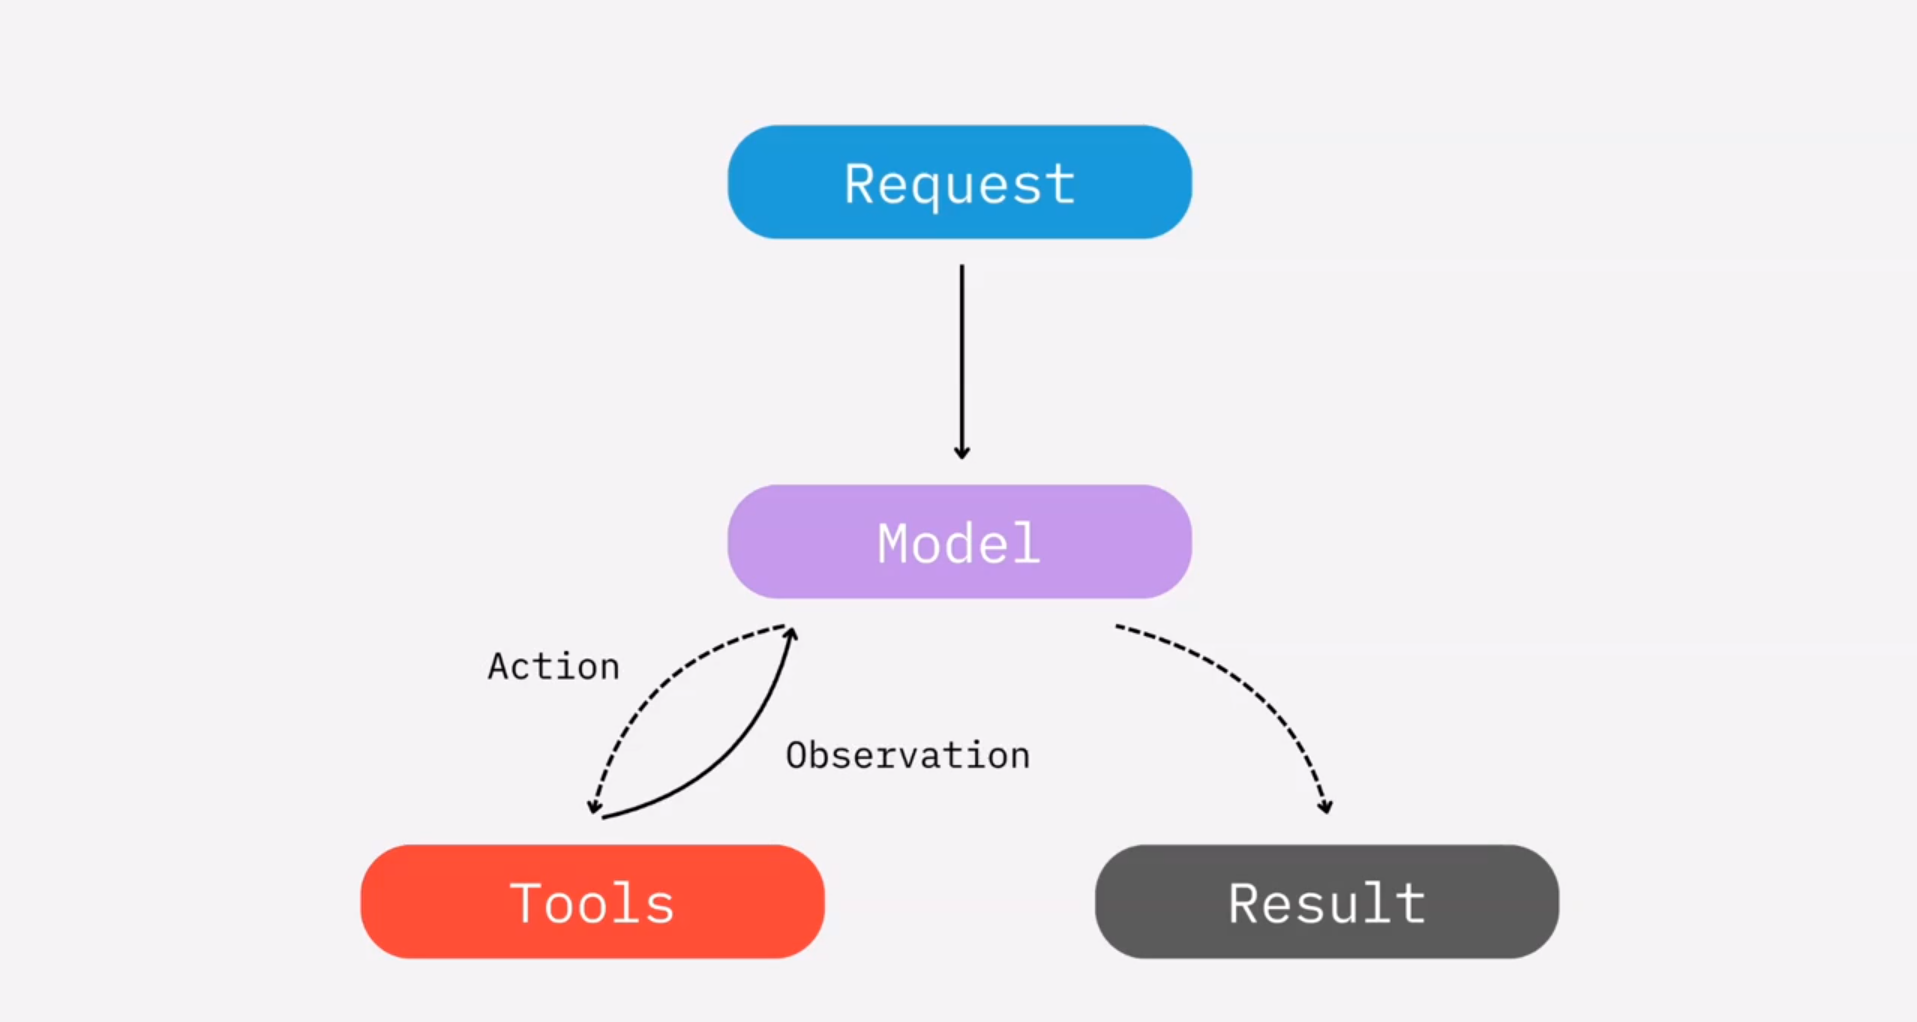

### 10. Tools

In [13]:
from langchain.tools import tool

# Defining Tool-``
@tool
def get_weather(city: str) -> str:
    '''Gives the current 
    weather in a given city.'''

    return f"The current weather in {city} is sunny."


agent = create_agent(model="google_genai:gemini-2.5-flash", 
                     tools=[get_weather])


result = agent.invoke({"messages": [HumanMessage(content= "What is the current weather of Lahore?")]})


pprint(result)

{'messages': [HumanMessage(content='What is the current weather of Lahore?', additional_kwargs={}, response_metadata={}, id='67e9881c-e2c3-481e-a7f8-ba206a7885d9'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "Lahore"}'}, '__gemini_function_call_thought_signatures__': {'d187dcff-542e-4b6d-8a72-fb5c7a3aab72': 'CoYCAWkUfRMYay2HpfjVWILiZnVm2QaSLAlHPs4s7gN/60NS27Zep6CF/6Z+c24Omq27zhEtfRP/IFNwx/M8SYPbSNqYBQgup3lpOv7yPO5zvpb+cUuBPPjiwc+fzNLfGkpgBzfUU0H26JDd992Sovd1BDOxLGDwKT+kGrHn71pUc8BbU39ctengL0OJtGGTo6ixNj9rwLkYUZInoDMCVKfveUVvQ3NYNkifHiSRRGjOQRavy6dEG6U+64rjs3Xq5saYHbbrqOWKT2xuIN95Kr/SUfpt2+Sq9dvHoZorBPS+96OaL3JqmGcIINZfFaFniG5H7hAKz/J+2PR0azLPST6wcpTJ1v1qSg=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0baa7-5ce1-79a3-9bda-f3cfa847990a-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Lahore'}, '

In [15]:
# Defining Tools
@tool
def get_weather(city: str) -> str:
    '''Gives the current 
    weather in a given city.'''

    return f"The current weather in {city} is sunny."

# Defining Tool-2
@tool
def fourth_root(x: float) -> float:
    """Calculate the 4th root of a number"""
    return x ** (1/4)

agent = create_agent(model="google_genai:gemini-2.5-flash", tools=[get_weather, fourth_root])


result = agent.invoke({"messages": [{"role": "user", "content": "what is the 4th root of 81?"}]})

pprint(result)

{'messages': [HumanMessage(content='what is the 4th root of 81?', additional_kwargs={}, response_metadata={}, id='032a3b9d-e401-40b1-9cfd-5d2a6ee8dccf'),
              AIMessage(content='', additional_kwargs={'function_call': {'name': 'fourth_root', 'arguments': '{"x": 81}'}, '__gemini_function_call_thought_signatures__': {'f57cebcf-cdff-4f24-ad1c-9b7ac2ba9d9f': 'CvUBAWkUfROPz9CuAsXway1c4KwzAcCKM11gNZ3QPahc1Dm+J+zq4aiGtvN1SyaGXVE27dXpNP7xV1eenKvKvLG8bOJnPeeWhR4VojD+A3KijfBKiFC4+tF90AOHZ01hH06Jp66Io9toZipmNXHWdJudzG5YT5QObRgcUUwgWjATOQy8QWlbsC+A4DBPIACebdf/hOtrxYojJLMxtMZP76wlIqnM3GMva/wDcq7ljNBlO5GBToSeGUC+nVouVpXSSS+UwbCY1dw7jzRwWp95mBbPDoA0OMjhte369jfotpYjVbtKVDzR/UcHxkGHgDX21r891AhvtWQ='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0baa8-a380-7433-96fd-e083b26c9e86-0', tool_calls=[{'name': 'fourth_root', 'args': {'x': 81}, 'id': 'f57cebcf-cdff-4f24-ad1c-9b7ac2ba9d9f', 'type': 

### 11. Structured output

In [ ]:
from pydantic import BaseModel

# Define a Pydantic model for structured output
class Answer(BaseModel):
    weather: str
    city: str

agent = create_agent(model="google_genai:gemini-2.5-flash", tools=[get_weather], response_format=Answer)


result = agent.invoke({"messages": [{"role": "user", "content": "what is the current weather of Lahore?"}]})

print(result["structured_response"])

output = result["structured_response"]

# Print the structured output as a dictionary
print(output.model_dump())


weather='sunny' city='Lahore'
{'weather': 'sunny', 'city': 'Lahore'}


### Web Search

In [5]:
# install langchain-tavily package
from tavily import TavilyClient
from dotenv import load_dotenv
from langchain.tools import tool

load_dotenv()

tavily_client = TavilyClient()

@tool
def web_search(query: str) -> dict:

    """Search the web for information"""

    return tavily_client.search(query)

web_search.invoke("Who is the current PM of Pakistan?")

{'query': 'Who is the current PM of Pakistan?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Prime_Minister_of_Pakistan',
   'title': 'Prime Minister of Pakistan - Wikipedia',
   'content': '| Prime Minister of Pakistan | |\n --- |\n| وزِیرِ اعظم پاکستان | |\n| State Emblem of Pakistan | |\n| Prime ministerial standard | |\n| Incumbent Shehbaz Sharif since 4 March 2024 | |\n| Executive branch of the Government of Pakistan | |\n| Style "Style (form of address)") |  The Honourable  Mr. Prime Minister (informal)  His Excellency (diplomatic) |\n| Type | Head of government |\n| Status | Leader of the House |\n| Abbreviation | PM | [...] | Executive "Executive (government)")   President of Pakistan: Asif Ali Zardari (PPP)  List of presidents of Pakistan  ---   Prime Minister of Pakistan: Shahbaz Sharif (PML-N "Pakistan Muslim League (N)"))  List of prime ministers of Pakistan  ---    Cabinet of Pakistan  Cabinet Secretary "

In [13]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage


agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=[web_search]
)

question = HumanMessage(content="Who is the current PM of Pakistan?")

response = agent.invoke(
    {"messages": [question]})



In [14]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='Who is the current PM of Pakistan?', additional_kwargs={}, response_metadata={}, id='39be0370-bc8d-494d-bbfe-83095e4ca1c8'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "current Prime Minister of Pakistan"}'}, '__gemini_function_call_thought_signatures__': {'call_948596': 'EnEKbwFpFH0TziUEWgrE/1OzfSPkbEirW+IDVDCxddeEJJkKMETpDy1dDtHkFY2pUhn/WthUzx3jsYgPVfaYMCiWRhddvl5q1+fcsqAyxfnFs92oNqgH4LhAW5gJcAD8tOpkH16xHCOuJvlDIBN6Fw4u7w=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0babe-4e86-7322-80d8-5a0d5aae8ec7-0', tool_calls=[{'name': 'web_search', 'args': {'query': 'current Prime Minister of Pakistan'}, 'id': 'call_948596', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 51, 'output_tokens': 20, 'total_tokens': 71, 'input_token_details': {'

In [15]:
print(response['messages'][-1].content[-1]['text'])

The current Prime Minister of Pakistan is **Shehbaz Sharif**. He assumed office for his current term on March 4, 2024.


### Assignment-1

##### Explore the Invocation and Streamimg in agents. Write a simple coding examples of these topics.

##### Create an Agent that can answer questions about the weather in a specific city. Explore the Free Weather API Platform to get the weather information. The agent should be able to take a city name as input and return the current weather conditions for that city.